In [2]:
# In[1] — thread caps (fork-safety / reproducibility)
import os
for v in ('OMP_NUM_THREADS','OPENBLAS_NUM_THREADS','MKL_NUM_THREADS',
          'VECLIB_MAXIMUM_THREADS','NUMEXPR_NUM_THREADS'):
    os.environ[v] = '1'

In [3]:
# In[2] — imports, path, reload, confirm the passthrough is in your repo
import sys, os, importlib, warnings, inspect
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

In [ ]:
import time as _t, os
import numpy as np, xarray as xr, seasonal_scan_harness as ssh
from xso.parscans import run_parallel_tasks
from baseline_r0_seasonal_comps import _build_fourier_func
forc_obs = ssh.build_forcings(['pre+recovery','post'])
def _smooth(m,n=2): return _build_fourier_func(m,period=365.0,n_harmonics=n)(np.linspace(0,365,365))
def _char(m):
    s=_smooth(m); return float(s.mean()), float((s.max()-s.min())/2), int(np.argmax(s))
POST_FN_M,POST_FN_A,POST_FN_PHI=_char(forc_obs['post']['fn']); PRE_FN_M,PRE_FN_A,_=_char(forc_obs['pre+recovery']['fn'])
POST_DE_M,POST_DE_A,_=_char(forc_obs['post']['de']); PRE_DE_M,PRE_DE_A,_=_char(forc_obs['pre+recovery']['de'])
POST_T_M,POST_T_A,_=_char(forc_obs['post']['t']);    PRE_T_M,PRE_T_A,_=_char(forc_obs['pre+recovery']['t'])
PHI=POST_FN_PHI; MID_DOY=np.array([15,46,74,105,135,166,196,227,258,288,319,349])
def sinusoidal_monthly(alpha):
    fn_m=POST_FN_M+alpha*(PRE_FN_M-POST_FN_M); fn_a=POST_FN_A+alpha*(PRE_FN_A-POST_FN_A)
    de_m=POST_DE_M+alpha*(PRE_DE_M-POST_DE_M); de_a=POST_DE_A+alpha*(PRE_DE_A-POST_DE_A)
    t_m =POST_T_M +alpha*(PRE_T_M -POST_T_M);  t_a =POST_T_A +alpha*(PRE_T_A -POST_T_A)
    c=np.cos(2*np.pi*(MID_DOY-PHI)/365)
    return {'fn':np.maximum(fn_m+fn_a*c,0.01),'de':np.maximum(de_m-de_a*c,5.0),'t':t_m-t_a*c}
ALPHAS=np.linspace(-0.5,2.0,50); R_F=np.linspace(0.0,0.6,50)
spec=ssh.allometry('maranon_ward'); GRZ={'KsZ':0.15,'sigma_log':0.20}
IVO={'GrazingRouter':{'gge':0.25},'FishGrazing':{'frac_D':0.25,'frac_export':0.25},
     'DetritusSink':{'w_sink':5.0},'DetritusRemin':{'k_remin':0.067},
     'ZooQuadMortality':{'frac_D':0.90,'frac_export':0.0},'ZooLinMortality':{'frac_D':0.90,'frac_export':0.0}}
combos=[(a,rf) for a in ALPHAS for rf in R_F]
tasks=[(dict(construct=spec, forcing=sinusoidal_monthly(a), fish_rate=float(rf), years=60, spinup=15,
             mP=0.0015, m_Z=0.10, grazing=GRZ, iv_overrides=IVO, n_harmonics=3, routed=True),) for a,rf in combos]  # ← no return_traj (default False)
shape=(len(ALPHAS),len(R_F))
def _empty(*d): return np.full((*shape,*d),np.nan)
SCALAR_FIELDS=['mcs','mcs_med','pico','pico_med','nano','nano_med','micro','micro_med',
               'sumP','sumP_med','sumZ','Z200','Z200_med','Z500','Z500_med','Z200_peak',
               'N','N_med','PP','PP_med','Export','Export_med',
               'cv_sumP','cv_sumZ','mcs_conv','minP','minZ','nan_frac','squiggle_sumP','squiggle_micro']
CLIM_FIELDS=['mcs','pico','nano','micro','sumP','Z200','Z500','N','PP']
scalars={k:_empty() for k in SCALAR_FIELDS}; clims={k:_empty(12) for k in CLIM_FIELDS}; HASN=np.zeros(shape,dtype=bool)
def on_result(item,done,n):
    k=item['index']; i,j=divmod(k,len(R_F))
    if not item['ok']: return
    clim=item['result']                       # ← result is the clim dict only now
    HASN[i,j]=bool(clim.get('has_nan',False))
    for f in SCALAR_FIELDS: scalars[f][i,j]=clim.get(f,np.nan)
    for f in CLIM_FIELDS:
        v=clim.get('clim_'+f)
        if v is not None and len(v)==12: clims[f][i,j,:]=v
t0=_t.perf_counter()
run_parallel_tasks(ssh._seasonal_worker, tasks, processes=None, on_result=on_result,
                   tally_flags=['has_nan'], label='fig5_A_50x50_v2', maxtasksperchild=1)
print(f"wall {(_t.perf_counter()-t0)/60:.1f} min | trips {int(HASN.sum())}/{HASN.size}")
os.makedirs('results',exist_ok=True); nc='results/fig5_alpha_sinusoidal_50x50_A_2026-06-29_v2.nc'
ds=xr.Dataset(
    data_vars={**{k:(('alpha','rF'),scalars[k]) for k in SCALAR_FIELDS},
               **{f'clim_{k}':(('alpha','rF','month'),clims[k]) for k in CLIM_FIELDS},
               'has_nan':(('alpha','rF'),HASN.astype(np.int8))},
    coords={'alpha':ALPHAS,'rF':R_F,'month':np.arange(1,13)},
    attrs=dict(construct='A: maranon_ward + Dutkiewicz Type III, ROUTED',
               KsZ=0.15, GGE=0.25, sigma_log=0.20, m_Z=0.10, mP=0.0015, w_sink=5.0, k_remin=0.067,
               fish_routing='N0.50/D0.25/export0.25', n_harmonics=3,
               era_markers='post (α=0, r_F=0.10); pre+rec (α=1, r_F=0.55)',
               stats='mean AND median stored per metric; figure statistic (mean vs median) TBD after inspecting output',
               years=60, spinup=15, created='2026-06-29'))
ds.to_netcdf(nc); print(f"saved {nc} ({os.path.getsize(nc)/1e6:.1f} MB)")

# PLOTTING

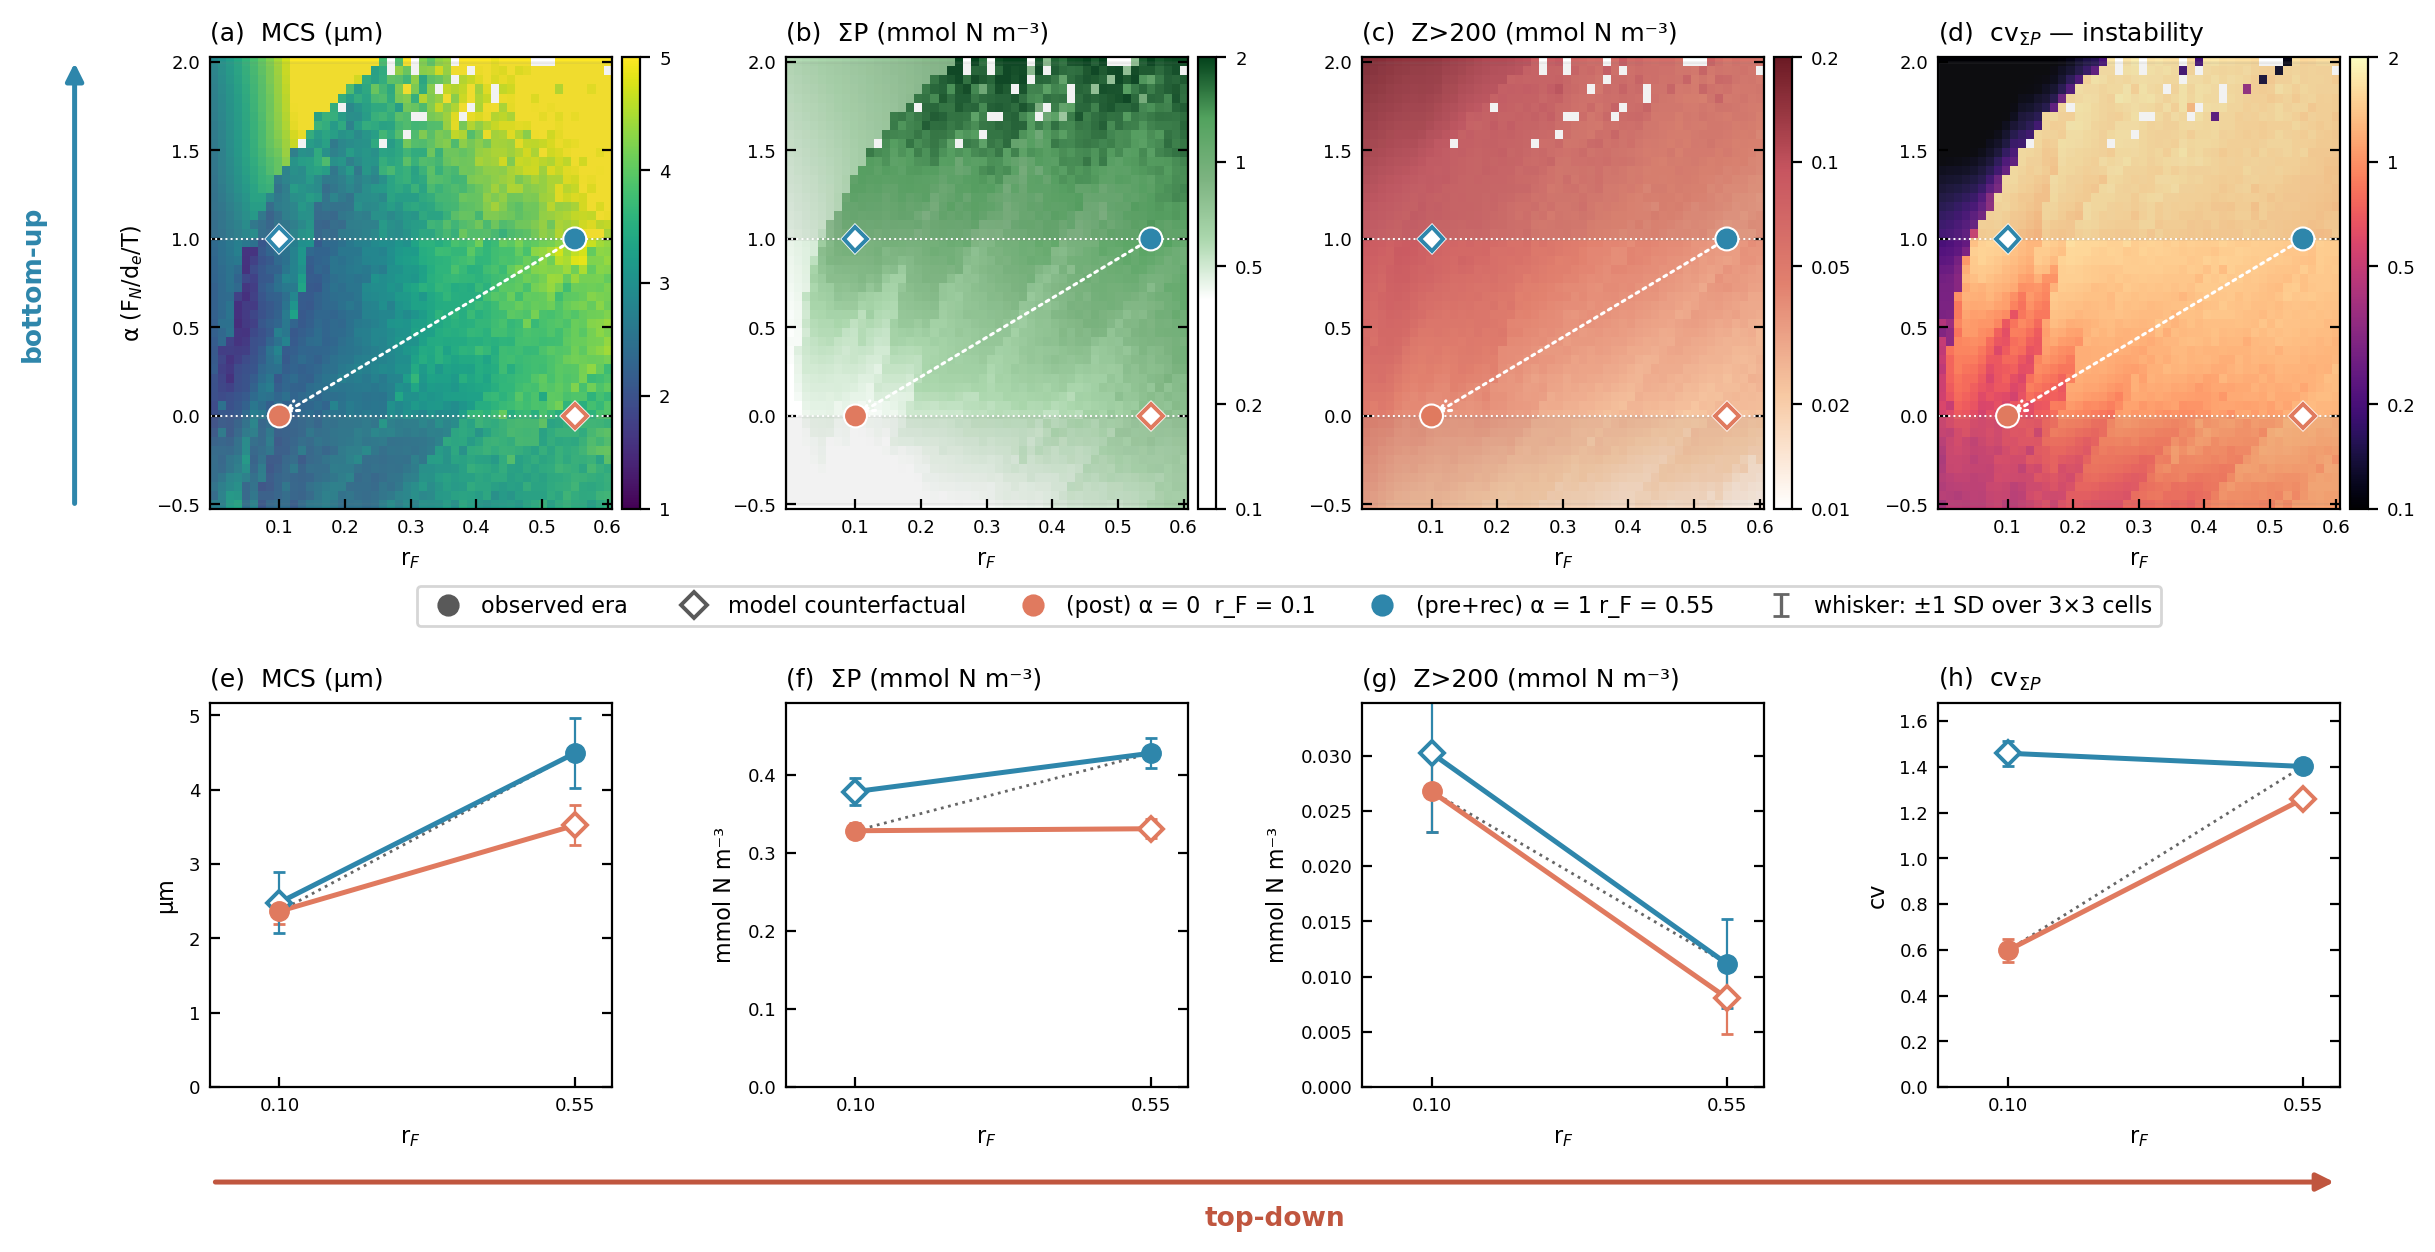

In [5]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt, xarray as xr
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm, Normalize, LinearSegmentedColormap
from matplotlib.ticker import NullLocator
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.axes_grid1 import make_axes_locatable

ds = xr.open_dataset('../../plots/results/fig5_alpha_sinusoidal_50x50_A_2026-06-29.nc')   # ← A
A_NAME, R_NAME, D_NAME = 'alpha', 'rF', 'day'
RF_MIN = 0.0; A0, A1, RL, RH = 0.0, 1.0, 0.1, 0.55; W = 1                     # ← A: RH 0.5→0.55
C_POST, C_PRE = '#E07A5F', '#2E86AB'
BU_COL, TD_COL = '#2E86AB', '#C0563F'                 # framing arrows: blue = bottom-up, red = top-down
HALO = [pe.withStroke(linewidth=2.0, foreground='white')]
cmap_phiP = LinearSegmentedColormap.from_list('phiP', ['white','#ABD7AD','#7CB380','#52A25E','#04421C'])
cmap_phiZ = LinearSegmentedColormap.from_list('phiZ', ['white','#F7C9A3','#E1806E','#C75560','#6B1A24'])
def style(ax): ax.tick_params(top=False, right=True, direction='in', labelsize=6.5)

dsf = ds.sel({R_NAME: slice(RF_MIN, None)})
alpha, R_F = dsf[A_NAME].values, dsf[R_NAME].values
av, rv = ds[A_NAME].values, ds[R_NAME].values
dr = R_F[1] - R_F[0]; XLIM = (R_F[0] - dr/2, R_F[-1] + dr/2)
def surf(k): return dsf[k].transpose(A_NAME, R_NAME).values
def corner(key, a, rf, mode):
    i = int(np.argmin(np.abs(av-a))); j = int(np.argmin(np.abs(rv-rf)))
    blk = ds[key].isel({A_NAME: slice(max(i-W,0),i+W+1), R_NAME: slice(max(j-W,0),j+W+1)})
    vals = (blk.median(D_NAME) if mode == 'traj' else blk).values
    return float(np.mean(vals)), float(np.std(vals))

def cell_marker(ax, x, y, col, era, zbase=6, halo=True):
    pe_ = HALO if halo else None
    if era:
        ax.plot(x, y, 'o', ms=7, color=col, mec=col, mew=0.5, zorder=zbase+2, path_effects=pe_)
    else:
        ax.plot(x, y, 'D', ms=6, mfc='white', mec=col, mew=1.4, zorder=zbase, path_effects=pe_)
CELLS = [(0.1, 0.0, C_POST, True), (0.55, 1.0, C_PRE, True),      # ← A: pre r_F 0.5→0.55
         (0.1, 1.0, C_PRE, False), (0.55, 0.0, C_POST, False)]    # ← A: 0.5→0.55

HEAT = [('mcs_med','MCS (µm)','viridis',False, 1.0, 5.0, [1,2,3,4,5]),
        ('sumP','ΣP (mmol N m⁻³)',cmap_phiP,True, 0.4, 2.0, [0.1,0.2,0.5,1.0,2.0]),
        ('Z200','Z>200 (mmol N m⁻³)',cmap_phiZ,True, 0.01, 0.2, [0.01,0.02,0.05,0.1,0.2]),
        ('cv_sumP','cv$_{ΣP}$ — instability','magma',True, 0.1, 2.0, [0.1,0.2,0.5,1,2])]
PANELS = [('MCS (µm)','traj_mcs','µm','traj'), ('ΣP (mmol N m⁻³)','traj_sumP','mmol N m⁻³','traj'),
          ('Z>200 (mmol N m⁻³)','traj_Z200','mmol N m⁻³','traj'), ('cv$_{ΣP}$','cv_sumP','cv','scalar')]
def heat_overlay(ax):
    ax.axhspan(alpha.min(), 0, color='0.5', alpha=0.10); ax.axhspan(1, alpha.max(), color='0.5', alpha=0.10)
    for y in (0,1): ax.axhline(y, color='white', lw=0.7, ls=':')
    ax.annotate('', xy=(0.1,0.0), xytext=(0.55,1.0),             # ← A: era diagonal pre 0.5→0.55
                arrowprops=dict(arrowstyle='->', lw=1.1, color='white', ls=':'), zorder=6)
    for rf, a, col, era in CELLS: cell_marker(ax, rf, a, col, era)

fig = plt.figure(figsize=(13, 6.6))
gs = GridSpec(3, 4, figure=fig, height_ratios=[1.0, 0.05, 0.85],
              left=0.10, right=0.93, top=0.91, bottom=0.13, hspace=0.30, wspace=0.34)
heat0 = int0 = int3 = None
for ci, (key, label, cmap, logf, vmin, vmax, ticks) in enumerate(HEAT):
    ax = fig.add_subplot(gs[0, ci]); s = surf(key)
    if ci == 0: heat0 = ax
    norm = LogNorm(vmin=vmin, vmax=vmax) if logf else Normalize(vmin=vmin, vmax=vmax)
    pc = ax.pcolormesh(R_F, alpha, s, shading='nearest', cmap=cmap, norm=norm)
    heat_overlay(ax); ax.set_title(f'({"abcd"[ci]})  {label}', fontsize=9, loc='left')
    ax.set_xlabel('r$_F$', fontsize=8); ax.set_xlim(XLIM); ax.set_xticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
    if ci == 0: ax.set_ylabel(r'α (F$_N$/d$_e$/T)', fontsize=8)
    style(ax)
    cax = make_axes_locatable(ax).append_axes("right", size="4.5%", pad=0.05)
    cb = fig.colorbar(pc, cax=cax)
    cb.set_ticks(ticks); cb.ax.set_yticklabels([f'{v:g}' for v in ticks])
    cb.ax.yaxis.set_minor_locator(NullLocator()); cb.ax.tick_params(labelsize=6.5)

# ---- slim full-width legend between the rows ----
legax = fig.add_subplot(gs[1, :]); legax.axis('off')
eb = legax.errorbar([np.nan], [np.nan], yerr=[1.0], fmt='none', ecolor='0.4',
                    elinewidth=1.2, capsize=3, label='whisker: ±1 SD over 3×3 cells')
leg_handles = [
    Line2D([],[], marker='o', ls='', mfc='0.35',  mec='0.35', ms=7,            label='observed era'),
    Line2D([],[], marker='D', ls='', mfc='white', mec='0.35', mew=1.4, ms=6.5, label='model counterfactual'),
    Line2D([],[], marker='o', ls='', mfc=C_POST,  mec=C_POST, ms=7,            label='(post) α = 0  r_F = 0.1'),
    Line2D([],[], marker='o', ls='', mfc=C_PRE,   mec=C_PRE,  ms=7,            label='(pre+rec) α = 1 r_F = 0.55'),  # ← A: 0.5→0.55
    eb]
legax.legend(handles=leg_handles, loc='center', ncol=5, #mode='expand', frameon=False,
             fontsize=8, handletextpad=0.5, borderaxespad=0.0)

for ci, (label, key, unit, mode) in enumerate(PANELS):
    ax = fig.add_subplot(gs[2, ci])
    if ci == 0: int0 = ax
    if ci == 3: int3 = ax
    (M00,e00),(M10,e10),(M01,e01),(M11,e11) = (corner(key,A0,RL,mode), corner(key,A1,RL,mode),
                                               corner(key,A0,RH,mode), corner(key,A1,RH,mode))
    RF = [0.1, 0.55]                                              # ← A: 0.5→0.55
    ax.plot(RF, [M00,M01], '-', color=C_POST, lw=1.8, zorder=3)
    ax.plot(RF, [M10,M11], '-', color=C_PRE,  lw=1.8, zorder=3)
    ax.errorbar(RF, [M00,M01], yerr=[e00,e01], fmt='none', ecolor=C_POST, elinewidth=0.8, capsize=2, zorder=2)
    ax.errorbar(RF, [M10,M11], yerr=[e10,e11], fmt='none', ecolor=C_PRE,  elinewidth=0.8, capsize=2, zorder=2)
    ax.plot([0.1,0.55], [M00,M11], ls=':', color='0.4', lw=1.0, zorder=1)                                  # ← A: 0.5→0.55
    for x, val, col, era in [(0.1,M00,C_POST,True),(0.55,M11,C_PRE,True),(0.1,M10,C_PRE,False),(0.55,M01,C_POST,False)]:  # ← A: 0.5→0.55
        cell_marker(ax, x, val, col, era, halo=False)
    ax.set_xlim(XLIM); ax.set_xticks([0.1, 0.55]); ax.set_ylim(0, 1.15*max(M00,M10,M01,M11))                # ← A: xticks 0.5→0.55
    ax.set_xlabel('r$_F$', fontsize=8); ax.set_ylabel(unit, fontsize=8)
    ax.set_title(f'({"efgh"[ci]})  {label}', fontsize=9, loc='left'); style(ax)
    make_axes_locatable(ax).append_axes("right", size="4.5%", pad=0.05).set_visible(False)

# ---- framing arrows: bottom-up (blue, vertical) + top-down (red, horizontal) ----
fig.canvas.draw()
ph, pi0, pi3 = heat0.get_position(), int0.get_position(), int3.get_position()
def fig_arrow(p0, p1, col):
    a = FancyArrowPatch(p0, p1, arrowstyle='-|>', mutation_scale=13, lw=1.8, color=col)
    a.set_transform(fig.transFigure); fig.add_artist(a)
xb = ph.x0 - 0.052                                    # bottom-up, up the left margin of the heatmap row
fig_arrow((xb, ph.y0), (xb, ph.y1), BU_COL)
fig.text(xb - 0.016, 0.5*(ph.y0+ph.y1), 'bottom-up', rotation=90, ha='center', va='center',
         fontsize=9.5, color=BU_COL, weight='bold')
yb = pi0.y0 - 0.072                                   # top-down, along the bottom under the data columns
fig_arrow((pi0.x0, yb), (pi3.x1, yb), TD_COL)
fig.text(0.5*(pi0.x0+pi3.x1), yb - 0.028, 'top-down', ha='center', va='center',
         fontsize=9.5, color=TD_COL, weight='bold')

#fig.suptitle('Figure 5 — bottom-up (α) × top-down (r$_F$): landscape (row 1) + 2×2 corner decomposition (row 2)  ·  construct D, idealised α-forcing',
#             fontsize=9.5, y=0.965)
#fig.savefig('results/Figure5_A_draft.pdf', bbox_inches='tight')   # ← A: _A so it won't overwrite your old draft
plt.show()

KeyError: "No variable named 'sumP_med'. Did you mean one of ('sumP', 'mcs_med')?"

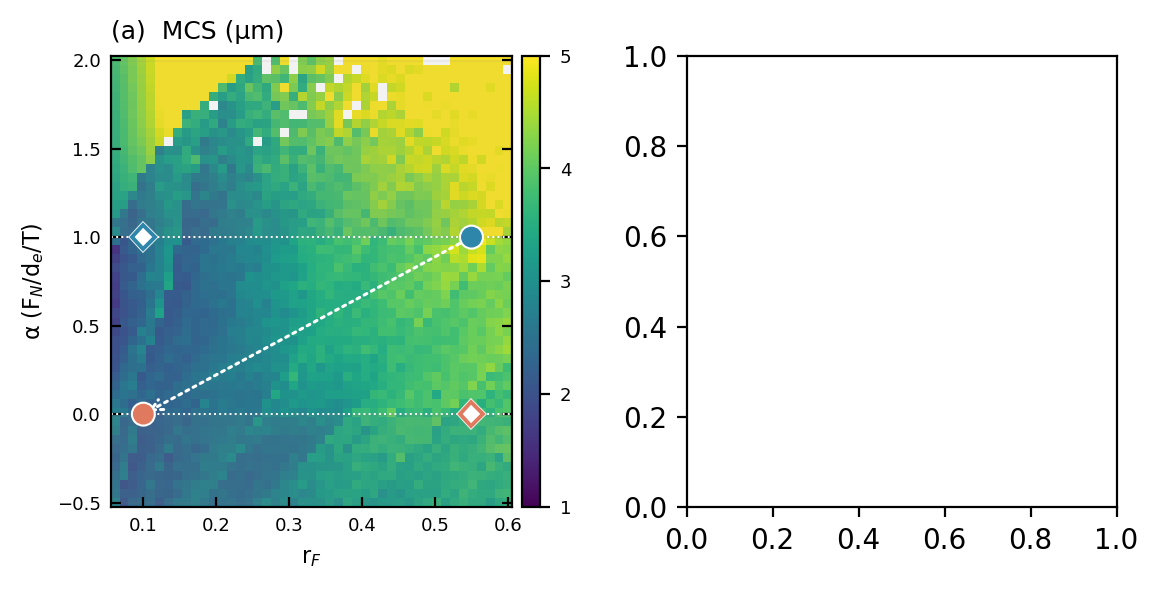

In [8]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt, xarray as xr
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm, Normalize, LinearSegmentedColormap
from matplotlib.ticker import NullLocator
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.axes_grid1 import make_axes_locatable
ds = xr.open_dataset('../../plots/results/fig5_alpha_sinusoidal_50x50_A_2026-06-29_v2.nc')   # ← v2 (median-stored)
A_NAME, R_NAME, D_NAME = 'alpha', 'rF', 'day'
RF_MIN = 0.05; A0, A1, RL, RH = 0.0, 1.0, 0.1, 0.55; W = 1
C_POST, C_PRE = '#E07A5F', '#2E86AB'; BU_COL, TD_COL = '#2E86AB', '#C0563F'
HALO = [pe.withStroke(linewidth=2.0, foreground='white')]
cmap_phiP = LinearSegmentedColormap.from_list('phiP', ['white','#ABD7AD','#7CB380','#52A25E','#04421C'])
cmap_phiZ = LinearSegmentedColormap.from_list('phiZ', ['white','#F7C9A3','#E1806E','#C75560','#6B1A24'])
def style(ax): ax.tick_params(top=False, right=True, direction='in', labelsize=6.5)
dsf = ds.sel({R_NAME: slice(RF_MIN, None)})
alpha, R_F = dsf[A_NAME].values, dsf[R_NAME].values
av, rv = ds[A_NAME].values, ds[R_NAME].values
dr = R_F[1]-R_F[0]; XLIM = (R_F[0]-dr/2, R_F[-1]+dr/2)
def surf(k): return dsf[k].transpose(A_NAME, R_NAME).values
def corner(key, a, rf, mode):
    i=int(np.argmin(np.abs(av-a))); j=int(np.argmin(np.abs(rv-rf)))
    blk=ds[key].isel({A_NAME:slice(max(i-W,0),i+W+1), R_NAME:slice(max(j-W,0),j+W+1)})
    vals=(blk.median(D_NAME) if mode=='traj' else blk).values
    return float(np.mean(vals)), float(np.std(vals))
def cell_marker(ax,x,y,col,era,zbase=6,halo=True):
    pe_=HALO if halo else None
    if era: ax.plot(x,y,'o',ms=7,color=col,mec=col,mew=0.5,zorder=zbase+2,path_effects=pe_)
    else:   ax.plot(x,y,'D',ms=6,mfc='white',mec=col,mew=1.4,zorder=zbase,path_effects=pe_)
CELLS = [(0.1,0.0,C_POST,True),(0.55,1.0,C_PRE,True),(0.1,1.0,C_PRE,False),(0.55,0.0,C_POST,False)]
# ← all MEDIAN now; colorbar ranges provisional for the median scale — adjust to data:
HEAT = [('mcs_med','MCS (µm)','viridis',False, 1.0, 5.0, [1,2,3,4,5]),
        ('sumP_med','ΣP (mmol N m⁻³)',cmap_phiP,True, 0.1, 1.0, [0.1,0.2,0.5,1.0]),
        ('Z200_med','Z>200 (mmol N m⁻³)',cmap_phiZ,True, 0.005, 0.05, [0.005,0.01,0.02,0.05]),
        ('cv_sumP','cv$_{ΣP}$ — instability','magma',True, 0.1, 2.0, [0.1,0.2,0.5,1,2])]
PANELS = [('MCS (µm)','mcs_med','µm','scalar'), ('ΣP (mmol N m⁻³)','sumP_med','mmol N m⁻³','scalar'),
          ('Z>200 (mmol N m⁻³)','Z200_med','mmol N m⁻³','scalar'), ('cv$_{ΣP}$','cv_sumP','cv','scalar')]   # ← _med + scalar
def heat_overlay(ax):
    ax.axhspan(alpha.min(),0,color='0.5',alpha=0.10); ax.axhspan(1,alpha.max(),color='0.5',alpha=0.10)
    for y in (0,1): ax.axhline(y,color='white',lw=0.7,ls=':')
    ax.annotate('', xy=(0.1,0.0), xytext=(0.55,1.0), arrowprops=dict(arrowstyle='->',lw=1.1,color='white',ls=':'), zorder=6)
    for rf,a,col,era in CELLS: cell_marker(ax,rf,a,col,era)
fig = plt.figure(figsize=(13,6.6))
gs = GridSpec(3,4,figure=fig,height_ratios=[1.0,0.05,0.85],left=0.10,right=0.93,top=0.91,bottom=0.13,hspace=0.30,wspace=0.34)
heat0=int0=int3=None
for ci,(key,label,cmap,logf,vmin,vmax,ticks) in enumerate(HEAT):
    ax=fig.add_subplot(gs[0,ci]); s=surf(key)
    if ci==0: heat0=ax
    norm=LogNorm(vmin=vmin,vmax=vmax) if logf else Normalize(vmin=vmin,vmax=vmax)
    pc=ax.pcolormesh(R_F,alpha,s,shading='nearest',cmap=cmap,norm=norm)
    heat_overlay(ax); ax.set_title(f'({"abcd"[ci]})  {label}',fontsize=9,loc='left')
    ax.set_xlabel('r$_F$',fontsize=8); ax.set_xlim(XLIM); ax.set_xticks([0.1,0.2,0.3,0.4,0.5,0.6])
    if ci==0: ax.set_ylabel(r'α (F$_N$/d$_e$/T)',fontsize=8)
    style(ax)
    cax=make_axes_locatable(ax).append_axes("right",size="4.5%",pad=0.05)
    cb=fig.colorbar(pc,cax=cax); cb.set_ticks(ticks); cb.ax.set_yticklabels([f'{v:g}' for v in ticks])
    cb.ax.yaxis.set_minor_locator(NullLocator()); cb.ax.tick_params(labelsize=6.5)
legax=fig.add_subplot(gs[1,:]); legax.axis('off')
eb=legax.errorbar([np.nan],[np.nan],yerr=[1.0],fmt='none',ecolor='0.4',elinewidth=1.2,capsize=3,label='whisker: ±1 SD over 3×3 cells')
leg_handles=[Line2D([],[],marker='o',ls='',mfc='0.35',mec='0.35',ms=7,label='observed era'),
    Line2D([],[],marker='D',ls='',mfc='white',mec='0.35',mew=1.4,ms=6.5,label='model counterfactual'),
    Line2D([],[],marker='o',ls='',mfc=C_POST,mec=C_POST,ms=7,label='(post) α = 0  r_F = 0.1'),
    Line2D([],[],marker='o',ls='',mfc=C_PRE,mec=C_PRE,ms=7,label='(pre+rec) α = 1 r_F = 0.55'), eb]
legax.legend(handles=leg_handles,loc='center',ncol=5,fontsize=8,handletextpad=0.5,borderaxespad=0.0)
for ci,(label,key,unit,mode) in enumerate(PANELS):
    ax=fig.add_subplot(gs[2,ci])
    if ci==0: int0=ax
    if ci==3: int3=ax
    (M00,e00),(M10,e10),(M01,e01),(M11,e11)=(corner(key,A0,RL,mode),corner(key,A1,RL,mode),corner(key,A0,RH,mode),corner(key,A1,RH,mode))
    RF=[0.1,0.55]
    ax.plot(RF,[M00,M01],'-',color=C_POST,lw=1.8,zorder=3); ax.plot(RF,[M10,M11],'-',color=C_PRE,lw=1.8,zorder=3)
    ax.errorbar(RF,[M00,M01],yerr=[e00,e01],fmt='none',ecolor=C_POST,elinewidth=0.8,capsize=2,zorder=2)
    ax.errorbar(RF,[M10,M11],yerr=[e10,e11],fmt='none',ecolor=C_PRE,elinewidth=0.8,capsize=2,zorder=2)
    ax.plot([0.1,0.55],[M00,M11],ls=':',color='0.4',lw=1.0,zorder=1)
    for x,val,col,era in [(0.1,M00,C_POST,True),(0.55,M11,C_PRE,True),(0.1,M10,C_PRE,False),(0.55,M01,C_POST,False)]:
        cell_marker(ax,x,val,col,era,halo=False)
    ax.set_xlim(XLIM); ax.set_xticks([0.1,0.55]); ax.set_ylim(0,1.15*max(M00,M10,M01,M11))
    ax.set_xlabel('r$_F$',fontsize=8); ax.set_ylabel(unit,fontsize=8)
    ax.set_title(f'({"efgh"[ci]})  {label}',fontsize=9,loc='left'); style(ax)
    make_axes_locatable(ax).append_axes("right",size="4.5%",pad=0.05).set_visible(False)
fig.canvas.draw()
ph,pi0,pi3=heat0.get_position(),int0.get_position(),int3.get_position()
def fig_arrow(p0,p1,col):
    a=FancyArrowPatch(p0,p1,arrowstyle='-|>',mutation_scale=13,lw=1.8,color=col); a.set_transform(fig.transFigure); fig.add_artist(a)
xb=ph.x0-0.052; fig_arrow((xb,ph.y0),(xb,ph.y1),BU_COL)
fig.text(xb-0.016,0.5*(ph.y0+ph.y1),'bottom-up',rotation=90,ha='center',va='center',fontsize=9.5,color=BU_COL,weight='bold')
yb=pi0.y0-0.072; fig_arrow((pi0.x0,yb),(pi3.x1,yb),TD_COL)
fig.text(0.5*(pi0.x0+pi3.x1),yb-0.028,'top-down',ha='center',va='center',fontsize=9.5,color=TD_COL,weight='bold')
#fig.savefig('results/Figure5_A_draft.pdf',bbox_inches='tight'); 
plt.show()